# Showcase — the Hunga Tonga eruption (January 2022)

The 15 January 2022 eruption of *Hunga Tonga–Hunga Haʻapai* was one of the most violent explosions ever recorded and all but erased the young volcanic island. This notebook pulls Sentinel-2 before/after composites, and uses the **NDWI** water index to measure how much sub-aerial **land disappeared**.

## What this notebook does

1. **Fetch** a pre- and post-eruption Sentinel-2 composite.
2. **Show** them side by side, and **outline the sub-aerial land** with the NDWI water index so the change in the island is easy to see.

Hunga Tonga sits under near-permanent tropical cloud, so this notebook stays deliberately qualitative — a clean cloud-free area measurement would need careful per-pixel cloud masking.

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY`; skips gracefully otherwise.

In [1]:
import os, tempfile, base64
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens
from pyramids.dataset import Dataset

logger.disable("earthlens"); logger.disable("pyramids")
SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")

def grab(collection, aoi, start, end, bands, scale, reducer="median"):
    """Download one GEE composite over [start,end]; return GeoTIFF path or None.
    aoi = [lon_min, lat_min, lon_max, lat_max]."""
    el = EarthLens(
        data_source="gee", start=start, end=end, temporal_resolution="raw",
        variables={collection: list(bands)},
        lat_lim=[aoi[1], aoi[3]], lon_lim=[aoi[0], aoi[2]],
        path=tempfile.mkdtemp(), scale=scale, reducer=reducer,
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY,
    )
    try:
        p = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001
        print("download skipped (needs GEE credentials):", exc); return None
    return str(p[0]) if p else None

def read(path):
    return np.asarray(Dataset.read_file(str(path)).read_array(), dtype="float32")

AOI = [-175.45, -20.62, -175.35, -20.52]   # Hunga Tonga-Hunga Ha'apai
C = "COPERNICUS/S2_SR_HARMONIZED"

# Month-long median composites (median quietly drops most tropical cloud).
# B4 red, B3 green, B2 blue (true colour); B8 NIR is used to outline land via NDWI.
before = grab(C, AOI, "2021-12-15", "2022-01-13", ["B4", "B3", "B2", "B8"], scale=10)
after  = grab(C, AOI, "2022-01-20", "2022-02-28", ["B4", "B3", "B2", "B8"], scale=10)
print("composites:", bool(before), bool(after))

composites: True True


## Before and after, with the land outlined

NDWI = (Green − NIR)/(NIR + Green) is positive over water and negative over land, so its zero contour traces the shoreline. The central island present in early January is gone afterwards (the remaining outlines are the two older islets and residual cloud).

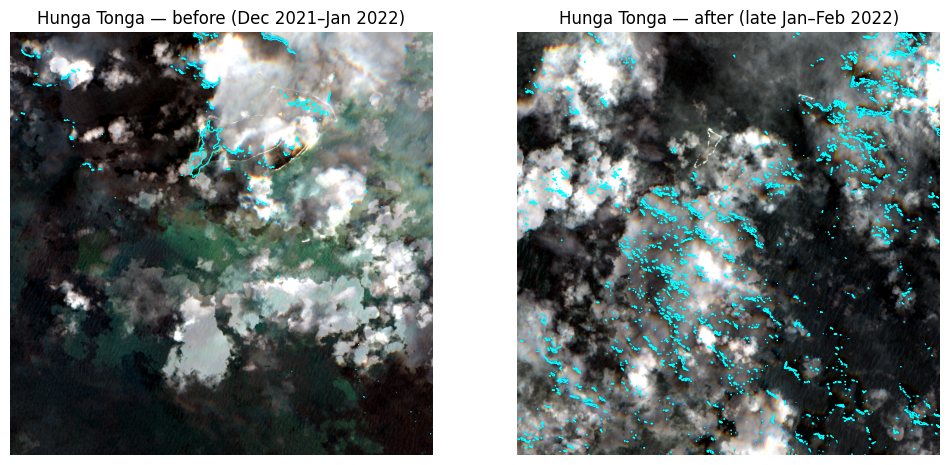

In [2]:
# True colour with the NDWI=0 shoreline drawn on top of each scene.
def tc(a):
    def st(b):
        lo, hi = np.nanpercentile(b, 2), np.nanpercentile(b, 98)
        return np.clip((b - lo) / (hi - lo + 1e-6), 0, 1)
    return np.dstack([st(a[i]) for i in range(3)])
def ndwi(a):
    g, nir = a[1], a[3]
    return (g - nir) / (g + nir + 1e-6)
if before and after:
    ab, aa = read(before), read(after)
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    for a_, arr, t in [(ax[0], ab, "before (Dec 2021–Jan 2022)"), (ax[1], aa, "after (late Jan–Feb 2022)")]:
        a_.imshow(tc(arr)); a_.contour(ndwi(arr), levels=[0.0], colors="cyan", linewidths=0.8)
        a_.set_title(f"Hunga Tonga — {t}"); a_.axis("off")
    plt.show()

## Recap

The before/after pair, with the NDWI shoreline drawn on, makes the island's destruction plain even through the cloud — the classic optical before/after that earthlens fetches in two calls.

## Try it yourself

- Add the SWIR band `B12` to highlight fresh ash and pumice rafts.
- Re-point `AOI` at another volcanic island or a coastline change.
- See the [GEE backend reference](../../reference/gee/introduction.md).